## Introduction




## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


## Section 1: Machine Learning is Improving Guesses Based on Loss (Error)

In the previous session, you learned how to calculate the loss - the deviation if a model's guess (prediction) from the observed value (target). Since the loss tells us how far we are from our target, we can use it to improve our next guess. If the loss increases between two guesses, we're not moving in the right direction and should try to update our model in a different direction for our next guess. We do this iteratively until we have improved our model as much as we can. Updating the parameters of a model to minimize the loss is what's referred to as "gradient descent". 

| Code | Description |
| --- | --- |
| `y_pred = a * x` | Make a prediction `y_pred` for an input `x` using the parameter `a` . |
| `loss_function(y_pred, y_obs)` | Calculate the loss of the prediction `y_pred`. |
| `grad_a = -2 * (y_obs - y_pred) * x` | Calculate the gradient of `a`. |
| `a = a - learning_rate * grad_a` | Update parameter `a` using the gradient and learning rate. |

In a hypothetical experiment, we want to quantify the relationship between the firing rate of a neuron in visual cortex and the brightness of a stimulus. Let's suppose that it's described by a simple linear equation where `x` is stimulus strength and `y` is the firing rate of the neuron:

$$y = a \times x$$

This equation is our model. But we don't know the parameter `a`, so we start by just taking a guess. We guess that `a = 2` and predict the firing rate for stimulus strength `x = 2` using the equation above. That gives us the predicted firing rate `y_pred = 4` Hz. Then, we compare this prediction to our recorded data by calculating the loss.

Run the cell below to create the variable `x` for stimulus strength and `y_obs` for observed firing rate.

In [2]:
x = torch.tensor(2.0)
y_obs = torch.tensor(10.0) # Hz

**Example**: Calculate the loss between the predicted firing rate `y_pred` and the observed firing rate `y_obs` using mean square error. Display the loss.

In [3]:
a = torch.tensor(3.0) # initial guess

y_pred = a * x # Hz

In [4]:
loss = nn.MSELoss()(y_pred, y_obs)
print(f'loss: {loss}')

loss: 16.0


Since that guess was off, we make a new guess. We guess that `a = 1`, which gives us a new firing rate prediction using the same equation<br>as above: `y_pred = a * x = 1 * 2 = 2`

**Exercise**: Calculate the loss between the predicted firing rate `y_pred` and the observed firing rate `y_obs` using mean square error. Display the loss.

In [33]:
a = torch.tensor(1.0) # new guess

y_pred = a * x # Hz

In [34]:
loss = nn.MSELoss()(y_pred, y_obs)
loss

tensor(64.)

The loss was even bigger, so we went in the wrong direction with that guess. We make a new guess in the opposite direction: `a = 4`.

**Exercise**: Calculate the loss between the predicted firing rate `y_pred` and the observed firing rate `y_obs` using mean square error. Display the loss.

In [35]:
a = torch.tensor(4.0) # new guess

y_pred = a * x # Hz

In [36]:
loss = nn.MSELoss()(y_pred, y_obs)
loss

tensor(4.)

That loss was smaller, so let's make a new guess in the same direction: `a = 5`.

**Exercise**: Calculate the loss between the predicted firing rate `y_pred` and the observed firing rate `y_obs` using mean square error. Display the loss.

In [37]:
a = torch.tensor(5.0) # new guess

y_pred = a * x # Hz

In [38]:
loss = nn.MSELoss()(y_pred, y_obs)
loss

tensor(0.)

**Demo**: We can write the iterative guessing above using a loop so we don't have to write the same code over and over.

In [39]:
for a in [3,2,4,5]:
    # make a prediction
    y_pred = a * x # Hz

    # calculate the loss
    loss = nn.MSELoss()(y_pred, y_obs)

    print(f'a: {a}, y_obs: {y_obs}, y_pred: {y_pred}, loss: {loss}')

a: 3, y_obs: 10.0, y_pred: 6.0, loss: 16.0
a: 2, y_obs: 10.0, y_pred: 4.0, loss: 36.0
a: 4, y_obs: 10.0, y_pred: 8.0, loss: 4.0
a: 5, y_obs: 10.0, y_pred: 10.0, loss: 0.0


Above, we manually changed the direction of the guess - whether to decrease or increase `a` - based on the loss. But the whole point of machine learning is that the machine should do this automatically.



Gradient descent offers a way to automatically determine which direction to change the parameters in order to minimize the loss. The gradient tells us how much the loss will change for a change in the parameter, and the equation (derivation[<sup>1</sup>](#fn1) at the bottom of this notebook) for the gradient of parameter `a` can be written as:

$$ 
\begin{align}
    grad_a &= \frac{\partial{loss}}{\partial{a}} &= -2 \times (y_{obs} - y_{pred}) \times x
    \tag{1}
\end{align}    
$$

The gradient is then used in an update rule for the next parameter guess. The update rule for the parameter `a` is expressed as follows:

$$ 
\begin{align}
    a_{next\ guess} &= a_{current\ guess} - \eta \times grad_a
    \tag{2}
\end{align}
$$

where $\eta$ is the learning rate (how much your parameters should change from one guess to the next).

We again start with an initial guess `a = 2`, predict a firing rate `y_pred` using this `a`, and calculate the loss.

**Example**: Calculate the gradient of `a` using equation (1) above. Looking at the update rule (2) for `a`, does a negative gradient suggest that the next `a` should be a bigger or smaller value?

In [40]:
a = torch.tensor(2.0) # initial guess

y_pred = a * x # Hz

# calculate the loss
loss = nn.MSELoss()(y_pred, y_obs)
loss

tensor(36.)

In [42]:
grad_a = -2 * (y_obs-y_pred) * x
grad_a

# a negative gradient will cancel out the minus sign in front of the learning rate in the update rule, 
# so it will lead to a bigger "a" in the next iteration

tensor(-24.)

In the cell below, `a` is updated using the update rule (2) and the gradient calculated in the example above. Then, a new firing rate is predicted using the updated `a`.

**Exercise**: Calculate and display the next gradient of `a`. Looking at the update rule (2) for `a`, does this gradient suggest that the next `a` should be a bigger or smaller value?

In [43]:
learning_rate = 0.1

a = a - learning_rate * grad_a

y_pred = a * x # Hz

loss = nn.MSELoss()(y_pred, y_obs)
print(f'a: {a:.2f}, loss: {loss:.2f}')

a: 4.40, loss: 1.44


In [44]:
grad_a = -2 * (y_obs - y_pred) * x
grad_a 

tensor(-4.8000)

**Exercise**: Calculate the next gradient of `a`. Display the gradient. Based on the update rule for `a`, does a this gradient suggest that the next `a` should be a bigger or smaller value?

In [45]:
learning_rate = 0.1

a = a - learning_rate * grad_a

y_pred = a * x # Hz

loss = nn.MSELoss()(y_pred, y_obs)
print(f'a: {a:.2f}, loss: {loss:.2f}')

a: 4.88, loss: 0.06


In [46]:
grad_a = -2 * (y_obs - y_pred) * x
grad_a 

tensor(-0.9600)

In the cell below, the `a` is updated again and the loss is calculated for the new prediction with the updated `a`.

**Exercise**: Calculate and display the next gradient of `a` using equation (1). Is the gradient smaller or bigger than in the example? Can you guess what it means if the gradient is smaller/bigger? (Think about the definition of the gradient: How big the change in the loss is for a change in the parameter.)

In [47]:
a = a - learning_rate * grad_a

y_pred = a * x # Hz

loss = nn.MSELoss()(y_pred, y_obs)
print(f'a: {a:.2f}, loss: {loss:.2f}')

a: 4.98, loss: 0.00


In [48]:
grad_a = -2 * (y_obs - y_pred) * x
grad_a 

tensor(-0.1920)

## Section 2: Learning Rate - How Fast Do We Learn

| Code | Description |
| --- | --- |
| `y_pred = a * x` | Make a prediction using parameter `a` and input `x`. |
| `grad_a = -2 * (y_obs - y_pred) * x` | Calculate the gradient of the loss with respect to parameter `a`. |
| `a = a - learning_rate * grad_a` | Update parameter `a` using the gradient and learning rate. |
| `learning_rate = some_num` | Define the learning rate hyperparameter, which controls the step size of<br>gradient descent. |

Run the cell below to create the variable `x` for stimulus strength and `y_obs` for observed firing rate.

In [49]:
x = torch.tensor(2.0)
y_obs = torch.tensor(10.0) # Hz

**Example**: Set `learning_rate = 0.1` and run the second cell below where `a` is changed according to the update rule from section 1: 
$$ a_{next} = a_{current} - \eta \times grad_a$$

where $\eta$ is the learning rate.

How much does `a` changed from before the update to after the update?

In [50]:
learning_rate = 0.1

In [51]:
a = torch.tensor(3.0) # initial guess
print(f'a before update: {a:.2f}')

y_pred = a * x # Hz
grad_a = -2 * (y_obs-y_pred) * x
a = a - learning_rate * grad_a

print(f'a after update: {a:.2f}')

a before update: 3.00
a after update: 4.60


**Exercise**: Set `learning_rate = 0.01` and run the second cell below where `a` is changed according to the update rule.

How much does `a` changed from before the update to after the update now?

In [52]:
learning_rate = 0.01

In [53]:
a = torch.tensor(3.0) # initial guess
print(f'a before update: {a:.2f}')

y_pred = a * x # Hz
grad_a = -2 * (y_obs-y_pred) * x
a = a - learning_rate * grad_a

print(f'a after update: {a:.2f}')

a before update: 3.00
a after update: 3.16


**Exercise**: Set `learning_rate = 1` and run the second cell below where `a` is changed according to the update rule.

How much does `a` changed from before the update to after the update now?

In [54]:
learning_rate = 1

In [55]:
a = torch.tensor(3.0) # initial guess
print(f'a before update: {a:.2f}')

y_pred = a * x # Hz
grad_a = -2 * (y_obs-y_pred) * x
a = a - learning_rate * grad_a

print(f'a after update: {a:.2f}')

a before update: 3.00
a after update: 19.00


Run the cell below to calculate the prediction and the loss of that prediction for our last updated `a`

In [56]:
a = torch.tensor(19.0)

y_pred = a * x # Hz

loss = nn.MSELoss()(y_pred, y_obs)

print(f'last a: {a:.2f}, y_obs: {y_obs}, y_pred: {y_pred:.2f}, loss: {loss:.3f}')

last a: 19.00, y_obs: 10.0, y_pred: 38.00, loss: 784.000


Saying that the learning rate determines how fast we learn makes it sound like a higher learning rate is always better. But as the last exercise may have indicated, if the learning rate is too high, the parameter update might be too big and we overshoot our target.

## Section 3: Visualizing the Loss Throughout Training

Printing the loss in each iteration is one useful way to check our model's performance throughout training, but it is also helpful to visualize the loss by plotting it, especially when we want to compare how well different model versions do on the same data. In order to plot the loss, we need to store it each time it's calculated. We can store it by appending the loss calculated to a list in each iteration. 

Below, the iteration is done with a for loop - a coding technique that's very useful when you do the same operation multiple times, as we do when we repeatedly calculate the loss for new predictions.

| Code | Description |
| --- | --- |
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |
| `for i in range(5):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 0 and 5 (not including 5)|
| `new_list = []`<br>`for i in range(5):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `element = 2*i` <br> &nbsp;&nbsp;&nbsp;&nbsp; `new_list.append(element)` | Store the calculated `element` in each iteration in the list `new_list` |

Run the cell below to create the variable `x` for stimulus strength and `y_obs` for observed firing rate.

In [69]:
x = torch.tensor(2.0)
y_obs = torch.tensor(10.0) # Hz

**Example**: Here, we have a set of pre-calculated predictions in `y_preds`. We loop through the predictions to calculate the loss for each of them. Store each calculated loss below in a list named `losses` and display the list to check that the stored losses match the printed ones.

In [70]:
y_preds = torch.tensor([6, 8, 9.25, 9.75, 10])

loss_function = nn.MSELoss()
for epoch in range(5):
    loss = loss_function(y_preds[epoch], y_obs)

    print(f'epoch: {epoch}, y_pred: {y_preds[epoch]}, loss: {loss:.4f}')

epoch: 0, y_pred: 6.0, loss: 16.0000
epoch: 1, y_pred: 8.0, loss: 4.0000
epoch: 2, y_pred: 9.25, loss: 0.5625
epoch: 3, y_pred: 9.75, loss: 0.0625
epoch: 4, y_pred: 10.0, loss: 0.0000


In [71]:
loss_function = nn.MSELoss()

# initilize list for losses
losses = []
for epoch in range(5):
    loss = loss_function(y_preds[epoch], y_obs)

    # store loss in list
    losses.append(loss)

losses

[tensor(16.), tensor(4.), tensor(0.5625), tensor(0.0625), tensor(0.)]

**Exercise**: We have a different set of pre-calculated predictions in `y_preds`. Store the loss calculated for each prediction below in a list named `losses` and display them to check that the stored losses match the printed ones.

In [72]:
# provided
y_preds = torch.tensor([3, 6, 8.5, 9.25, 10])

for epoch in range(5):
    # calculate loss
    loss = nn.MSELoss()(y_preds[epoch], y_obs)

    print(f'epoch: {epoch}, y_pred: {y_preds[epoch]}, loss: {loss:.4f}')

epoch: 0, y_pred: 3.0, loss: 49.0000
epoch: 1, y_pred: 6.0, loss: 16.0000
epoch: 2, y_pred: 8.5, loss: 2.2500
epoch: 3, y_pred: 9.25, loss: 0.5625
epoch: 4, y_pred: 10.0, loss: 0.0000


In [73]:
loss_function = nn.MSELoss()

# initilize list for losses
losses = []
for epoch in range(5):
    loss = loss_function(y_preds[epoch], y_obs)

    # store loss in list
    losses.append(loss)

losses

[tensor(49.), tensor(16.), tensor(2.2500), tensor(0.5625), tensor(0.)]

**Exercise**: We have another set of pre-calculated predictions in `y_preds`. Store the loss calculated below in a list named `losses` and run the second cell to plot the losses. Do the plotted values match the printed values?

In [74]:
y_preds = torch.tensor([1, 5, 8, 9.5, 10])

loss_function = nn.MSELoss()

for epoch in range(5):
    # calculate loss
    loss = loss_function(y_preds[epoch], y_obs)

    print(f'epoch: {epoch}, loss: {loss:.4f}')

epoch: 0, loss: 81.0000
epoch: 1, loss: 25.0000
epoch: 2, loss: 4.0000
epoch: 3, loss: 0.2500
epoch: 4, loss: 0.0000


In [75]:
loss_function = nn.MSELoss()

# initilize list for losses
losses = []
for epoch in range(5):
    loss = loss_function(y_preds[epoch], y_obs)

    # store loss in list
    losses.append(loss)

Text(0.5, 1.0, 'Loss throughout training')

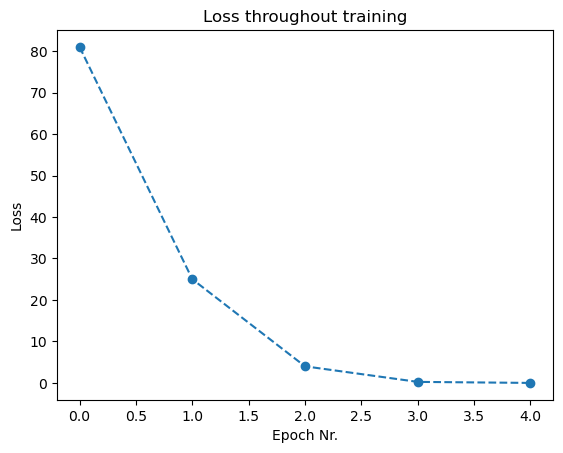

In [76]:
plt.plot(losses, 'o--')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')

By plotting the loss, we have a way to visuzalize how the learning rate affects the training of the model.

**Example**: Below, we train the model through gradient descent, like in section 1 and 2. Fill in the blank lines (marked by `___`) to
a) Set the learning rate to 0.1
b) Initialize a list named `losses_01` where losses can be stored
c) Append the calculeted loss in each iteration to the list `losses_01` to store it.

Then, run the cell to plot the loss throughout training with this learning rate.

In [79]:
learning_rate = ___

a = torch.tensor(3.0) # initial guess

loss_function = nn.MSELoss()

# initilize list for losses
___
for epoch in range(5):
    print(f'epoch: {epoch}, a: {a:.2f}')
    y_pred = a * x # Hz
    loss = loss_function(y_pred, y_obs)
    grad_a = -2 * (y_obs-y_pred) * x
    a = a - learning_rate * grad_a
    
    # store the loss
    ___

plt.plot(losses_01, 'o--', label = 'learning rate = 0.1')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')
plt.legend()

epoch: 0, a: 3.00


TypeError: only integer tensors of a single element can be converted to an index

epoch: 0, a: 3.00
epoch: 1, a: 4.60
epoch: 2, a: 4.92
epoch: 3, a: 4.98
epoch: 4, a: 5.00


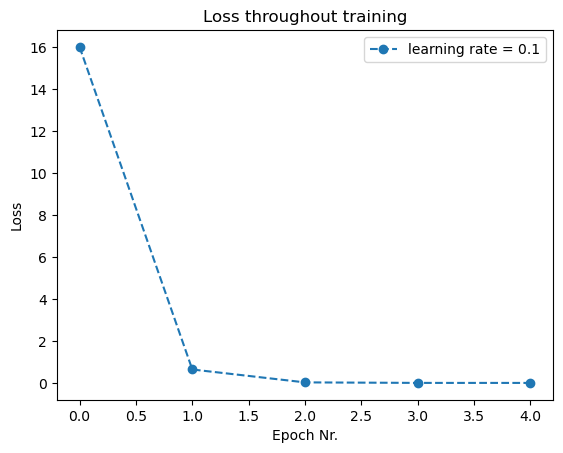

In [80]:
'''Solution:'''

learning_rate = 0.1

a = torch.tensor(3.0) # initial guess

loss_function = nn.MSELoss()

# initilize list for losses
losses_01 = []
for epoch in range(5):
    print(f'epoch: {epoch}, a: {a:.2f}')
    y_pred = a * x # Hz
    loss = loss_function(y_pred, y_obs)
    grad_a = -2 * (y_obs-y_pred) * x
    a = a - learning_rate * grad_a
    
    # store the loss
    losses_01.append(loss)

plt.plot(losses_01, 'o--', label = 'learning rate = 0.1')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')
plt.legend()

**Exercise**: Below, we train the model through gradient descent, like in section 1 and 2. Fill in the blank lines (marked by `___`) to
a) Set the learning rate to 0.01
b) Initialize a list named `losses_001` where losses can be stored
c) Append the calculeted loss in each iteration to the list `losses_001` to store it.

Then, run the cell to plot the loss throughout training for both this learning rate and the learning rate in the example above. Which learning rate appears best of the two?

In [ ]:
learning_rate = ___

a = torch.tensor(3.0) # initial guess

loss_function = nn.MSELoss()

# initilize list for losses
___
for epoch in range(5):
    print(f'epoch: {epoch}, a: {a:.2f}')
    y_pred = a * x # Hz
    loss = loss_function(y_pred, y_obs)
    grad_a = -2 * (y_obs-y_pred) * x
    a = a - learning_rate * grad_a
    
    # store the loss
    ___

plt.plot(losses_01, 'o--', label='learning rate = 0.1')
plt.plot(losses_001, 'o--', label='learning rate = 0.01')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')
plt.legend()

epoch: 0, a: 3.00
epoch: 1, a: 3.16
epoch: 2, a: 3.31
epoch: 3, a: 3.44
epoch: 4, a: 3.57


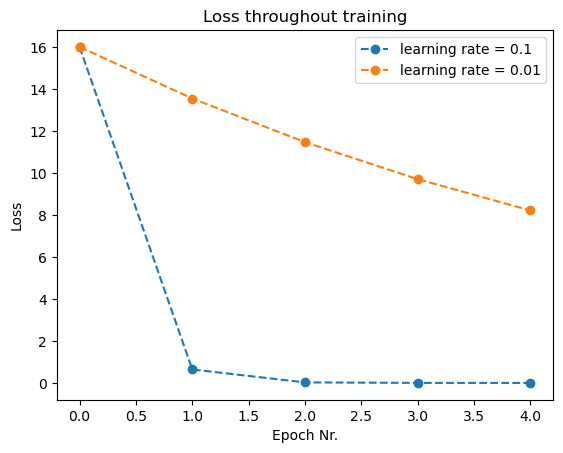

In [82]:
learning_rate = 0.01

a = torch.tensor(3.0) # initial guess

loss_function = nn.MSELoss()

# initilize list for losses
losses_001 = []
for epoch in range(5):
    print(f'epoch: {epoch}, a: {a:.2f}')
    y_pred = a * x # Hz
    loss = loss_function(y_pred, y_obs)
    grad_a = -2 * (y_obs-y_pred) * x
    a = a - learning_rate * grad_a
    
    # store the loss
    losses_001.append(loss)

plt.plot(losses_01, 'o--', label='learning rate = 0.1')
plt.plot(losses_001, 'o--', label='learning rate = 0.01')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')
plt.legend()

**Exercise**: Below, we train the model through gradient descent, like in section 1 and 2. Fill in the blank lines (marked by `___`) to
a) Set the learning rate to 0.3
b) Initialize a list named `losses_03` where losses can be stored
c) Append the calculeted loss in each iteration to the list `losses_03` to store it.

Then, run the cell to plot the loss throughout training for both this learning rate and the learning rate in the example above. What happens to the loss when the learning_rate is `0.3`?

In [ ]:
learning_rate = ___

a = torch.tensor(3.0) # initial guess

loss_function = nn.MSELoss()

# initilize list for losses
___
for epoch in range(5):
    print(f'epoch: {epoch}, a: {a:.2f}')
    y_pred = a * x # Hz
    loss = loss_function(y_pred, y_obs)
    grad_a = -2 * (y_obs-y_pred) * x
    a = a - learning_rate * grad_a
    
    # store the loss
    ___

plt.plot(losses_01, 'o--', label='learning rate = 0.1')
plt.plot(losses_001, 'o--', label='learning rate = 0.01')
plt.plot(losses_03, 'o--', label='learning rate = 0.3')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')
plt.legend()

epoch: 0, a: 3.00
epoch: 1, a: 7.80
epoch: 2, a: 1.08
epoch: 3, a: 10.49
epoch: 4, a: -2.68


epoch: 0, a: 3.00
epoch: 1, a: 7.80
epoch: 2, a: 1.08
epoch: 3, a: 10.49
epoch: 4, a: -2.68


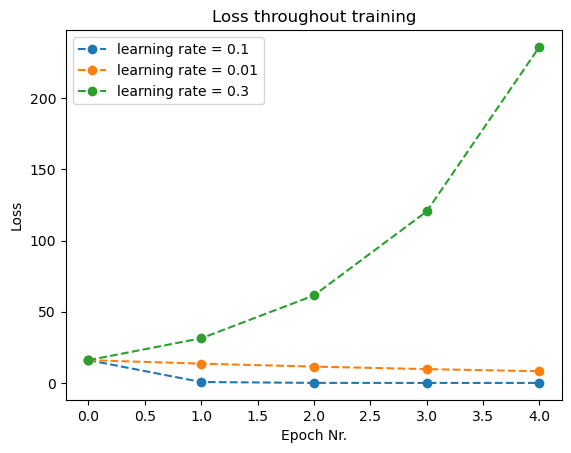

In [83]:
learning_rate = 0.3

a = torch.tensor(3.0) # initial guess

loss_function = nn.MSELoss()

# initilize list for losses
losses_03 = []
for epoch in range(5):
    print(f'epoch: {epoch}, a: {a:.2f}')
    y_pred = a * x # Hz
    loss = loss_function(y_pred, y_obs)
    grad_a = -2 * (y_obs-y_pred) * x
    a = a - learning_rate * grad_a
    
    # store the loss
    losses_03.append(loss)

plt.plot(losses_01, 'o--', label='learning rate = 0.1')
plt.plot(losses_001, 'o--', label='learning rate = 0.01')
plt.plot(losses_03, 'o--', label='learning rate = 0.3')
plt.xlabel('Epoch Nr.')
plt.ylabel('Loss')
plt.title('Loss throughout training')
plt.legend()

## Section 4(?): Machine Learning is iterative guessing.  Iteration can be done with For Loops.

As you may have noticed above, we do the same set of operations over and over again in machine learning. After the initial guess
1. Make a prediction.
2. Calculate the loss of that prediction.
3. Calculate the gradient of the parameters based on that loss.
4. Update the parameters using the gradient
5. Repeat steps 1-4 until the model no longer improves.

When you train a neural network, you're making the model guess what the output should be over and over again. Between each guess, the model parameters are updated until the guess is good enough. In other words, it's an iterative improvement of the model. This iteration can be programmed with a for loop. A for loop lets us perform an operation a predefined number of times and is an incredibly useful programming concept. In this section, you will get som practice writing for loops.

| Code | Description |
| --- | --- |


#### **Exercises**

Like before, we can put this iterative guessing in a loop so we don't have to write the code and run the cells over and over.

In [ ]:
a = torch.tensor(3.0) # initial guess
learning_rate = 0.1

# put the code below in a for loop with 5 iterations
for epoch in range(5):
    y_pred = a * x # Hz

    loss = nn.MSELoss()(y_pred, y_obs)
    
    print(f'epoch: {epoch}, a: {a:.2f}, y_obs: {y_obs}, y_pred: {y_pred:.2f}, loss: {loss:.3f}')
    
    grad_a = -2 * (y_obs-y_pred) * x

    a = a - learning_rate * grad_a

epoch: 0, a: 3.00, y_obs: 10.0, y_pred: 6.00, loss: 16.000
epoch: 1, a: 3.16, y_obs: 10.0, y_pred: 6.32, loss: 13.542
epoch: 2, a: 3.31, y_obs: 10.0, y_pred: 6.61, loss: 11.462
epoch: 3, a: 3.44, y_obs: 10.0, y_pred: 6.89, loss: 9.702
epoch: 4, a: 3.57, y_obs: 10.0, y_pred: 7.13, loss: 8.212


In [107]:
torch.tensor(y_preds001)

tensor([6.0000, 6.3200, 6.6144, 6.8852, 7.1344])

In [104]:
torch.tensor(y_preds01)

tensor([6.0000, 9.2000, 9.8400, 9.9680, 9.9936])

#### <span id="fn1"><sup>1</sup>Derivation of Gradient Equation

The gradient tells us how much the loss changes if we change a parameter in our model. In mathematical terms, the gradient is the derivative of the loss with respect to the parameter.

The math below shows how the gradient for `a` is derived if you want to know where the final equation comes from. We start with definition of the gradient: the change in loss ($`\Delta loss`$) per change in the parameter ($`\Delta a`$).

$$grad_a = \frac{\Delta loss}{\Delta a}$$

When the change in `a` is small, this can be written as a differential equation:

$$grad_a = \frac{\partial{loss}}{\partial{a}}$$

we insert $loss = (y_{obs}-y_{pred})^2$

$$ grad_a = \frac{\partial{((y_{obs}-y_{pred})^2})}{\partial{a}}$$

we insert $y_{pred} = a \times x$

$$ grad_a = \frac{\partial{((y_{obs}-a \times x)^2)}}{\partial{a}}$$

we calculate the derivative using the [chain rule](https://en.wikipedia.org/wiki/Chain_rule)

$$ grad_a = \frac{\partial (u^2)}{\partial u} \times \frac{\partial (y_{obs}-ax)}{\partial a} $$

where $u = y_{obs}-a \times x$. Carrying out the derivation, we get:

$$ grad_a = -2(y_{obs}-a \times x) \times x$$

we write $`y_{pred}`$ instead of $`a \times x`$ in the final equation

$$ grad_a = -2(y_{obs}-y_{pred}) \times x$$

Using more mathematical notation with the gradient expressed with $\nabla$ and $\mathcal{L}$ for the loss, we get:

$$ \nabla_a(\mathcal{L}) = -2 \times (y_{obs}-y_{pred}) \times x$$